# LLMnetopsLab — Results Visualization

Visualizations of 50 experimental runs where Claude Code (Opus 4.6) autonomously diagnosed and resolved OSPF faults on a 3-router VyOS topology.

In [1]:
import json
import subprocess
import sys
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

# Publication-quality defaults
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.figsize': (8, 5),
    'hatch.linewidth': 0.6,
    'patch.edgecolor': 'black',
})
sns.set_style('whitegrid')

# Paths
ROOT = Path('..').resolve()
SCRIPTS = ROOT / 'scripts'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

# Load data from analysis scripts
result = subprocess.run(
    [sys.executable, str(SCRIPTS / 'parse_results.py'), str(ROOT / 'results' / 'verify'), '--format', 'json'],
    capture_output=True, text=True
)
outcomes = json.loads(result.stdout)

result = subprocess.run(
    [sys.executable, str(SCRIPTS / 'parse_transcripts.py'), str(ROOT / 'results' / 'cctranscripts'), '--format', 'json'],
    capture_output=True, text=True
)
transcripts = json.loads(result.stdout)

print(f"Loaded {outcomes['aggregate']['total_runs']} outcome runs")
print(f"Loaded {transcripts['aggregate']['total_runs']} transcript runs")

# Store all figures for export
all_figures = []

Loaded 50 outcome runs
Loaded 50 transcript runs


## Adjusted Scores

37 runs scored 5/6 because Error #3 was resolved with `default-information originate always` instead of `default-information originate`. Both commands are functionally equivalent. The adjusted score treats the `always` variant as a valid fix.

In [2]:
# Compute original and adjusted scores per run
runs_df = []
for r in outcomes['per_run']:
    original_score = r['error_statuses']['fixed_count']
    # Adjusted: if error 3 is among the broken errors, count it as fixed
    # (the "always" variant of default-information originate is functionally equivalent)
    if 3 in r['error_statuses']['broken']:
        adjusted_score = original_score + 1
    else:
        adjusted_score = original_score
    runs_df.append({
        'run': r['filename'],
        'original_score': original_score,
        'adjusted_score': adjusted_score,
    })

scores_df = pd.DataFrame(runs_df)

orig_perfect = (scores_df['original_score'] == 6).sum()
adj_perfect = (scores_df['adjusted_score'] == 6).sum()
print(f"Original perfect runs: {orig_perfect}/50 ({orig_perfect*2}%)")
print(f"Adjusted perfect runs: {adj_perfect}/50 ({adj_perfect*2}%)")

Original perfect runs: 11/50 (22%)
Adjusted perfect runs: 48/50 (96%)


## Figure 1 — Per-Error Fix Rate (Original vs. Adjusted)

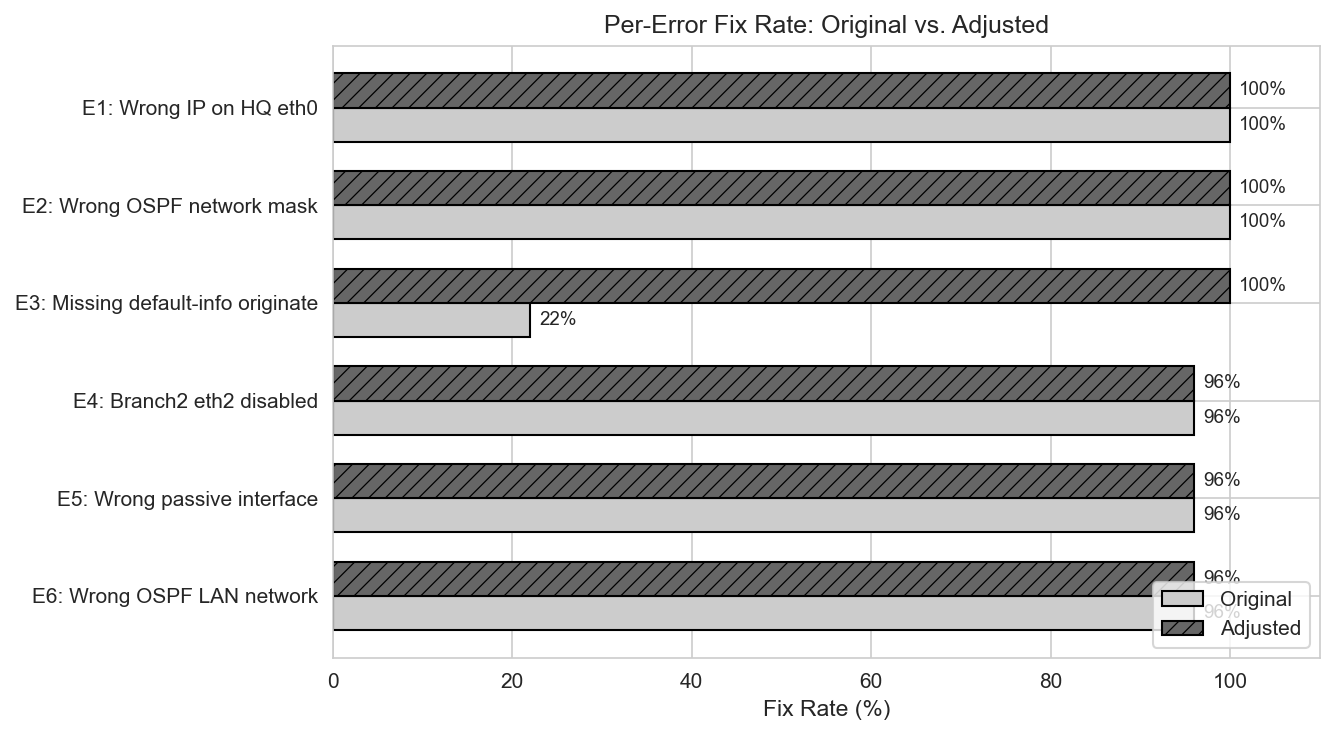

In [3]:
error_data = outcomes['aggregate']['per_error_fix_rate']

error_ids = sorted(error_data.keys(), key=int)
descriptions = [error_data[e]['description'] for e in error_ids]
# Shorten descriptions for readability
short_desc = [
    'E1: Wrong IP on HQ eth0',
    'E2: Wrong OSPF network mask',
    'E3: Missing default-info originate',
    'E4: Branch2 eth2 disabled',
    'E5: Wrong passive interface',
    'E6: Wrong OSPF LAN network',
]
original_rates = [error_data[e]['fix_rate'] * 100 for e in error_ids]
# Adjusted: error 3 becomes 100% (always variant counted as fix)
adjusted_rates = [r if i != 2 else 100.0 for i, r in enumerate(original_rates)]

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(short_desc))
bar_height = 0.35

bars_orig = ax.barh(y + bar_height/2, original_rates, bar_height, label='Original',
                    color='#cccccc', edgecolor='black')
bars_adj = ax.barh(y - bar_height/2, adjusted_rates, bar_height, label='Adjusted',
                   color='#666666', edgecolor='black', hatch='///')

ax.set_yticks(y)
ax.set_yticklabels(short_desc)
ax.set_xlabel('Fix Rate (%)')
ax.set_xlim(0, 110)
ax.set_title('Per-Error Fix Rate: Original vs. Adjusted')
ax.legend(loc='lower right')

# Annotate values
for bar in bars_orig:
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2, f'{w:.0f}%', va='center', fontsize=9)
for bar in bars_adj:
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2, f'{w:.0f}%', va='center', fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
all_figures.append(('fig1_error_fix_rates', fig))
plt.show()

## Figure 2 — Score Distribution: Original vs. Adjusted

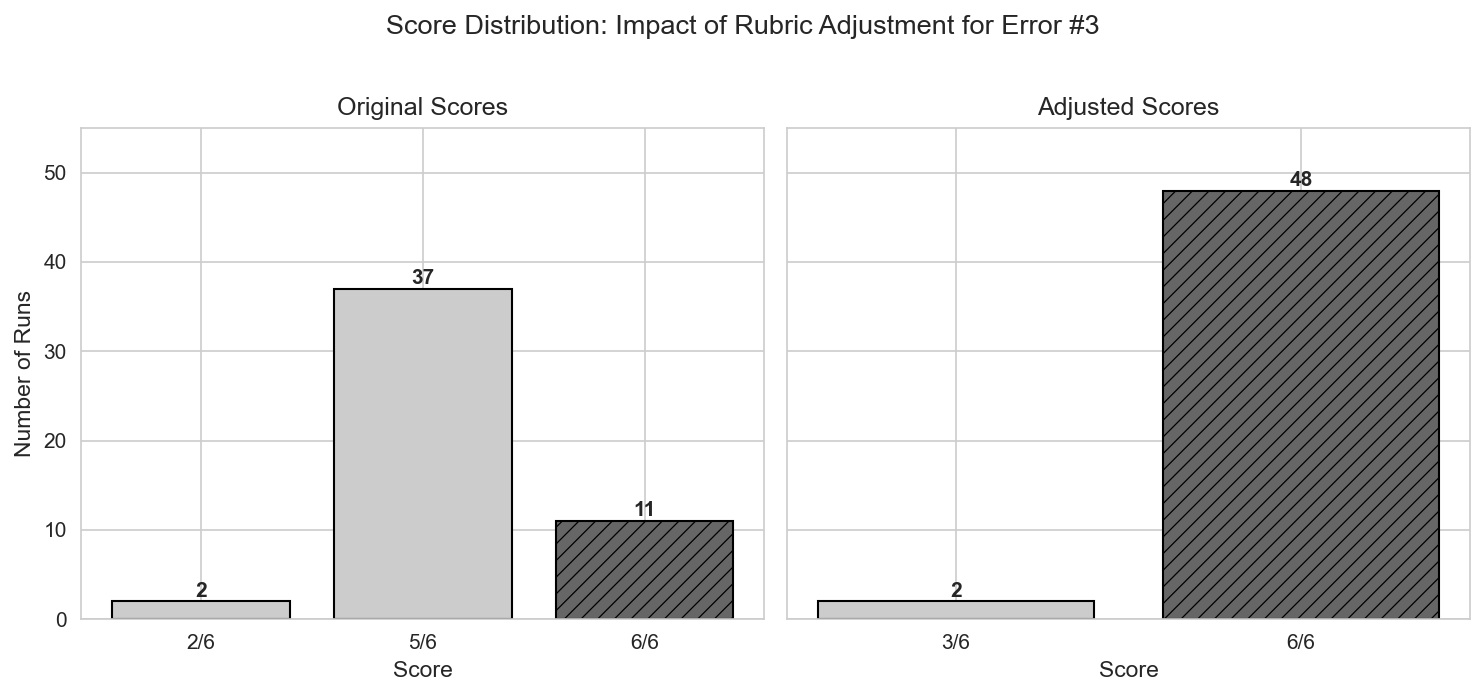

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

def style_for(score):
    if score == 6:
        return {'color': '#666666', 'hatch': '///'}
    return {'color': '#cccccc', 'hatch': ''}

# Original distribution
orig_counts = scores_df['original_score'].value_counts().sort_index()
for i, (s, v) in enumerate(orig_counts.items()):
    style = style_for(s)
    ax1.bar(f'{s}/6', v, color=style['color'], edgecolor='black', hatch=style['hatch'])
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
ax1.set_title('Original Scores')
ax1.set_xlabel('Score')
ax1.set_ylabel('Number of Runs')
ax1.set_ylim(0, 55)

# Adjusted distribution
adj_counts = scores_df['adjusted_score'].value_counts().sort_index()
for i, (s, v) in enumerate(adj_counts.items()):
    style = style_for(s)
    ax2.bar(f'{s}/6', v, color=style['color'], edgecolor='black', hatch=style['hatch'])
    ax2.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
ax2.set_title('Adjusted Scores')
ax2.set_xlabel('Score')
ax2.set_ylim(0, 55)

fig.suptitle('Score Distribution: Impact of Rubric Adjustment for Error #3', fontsize=13, y=1.02)
plt.tight_layout()
all_figures.append(('fig2_score_distribution', fig))
plt.show()

## Figure 3 — Duration and Cost Distributions

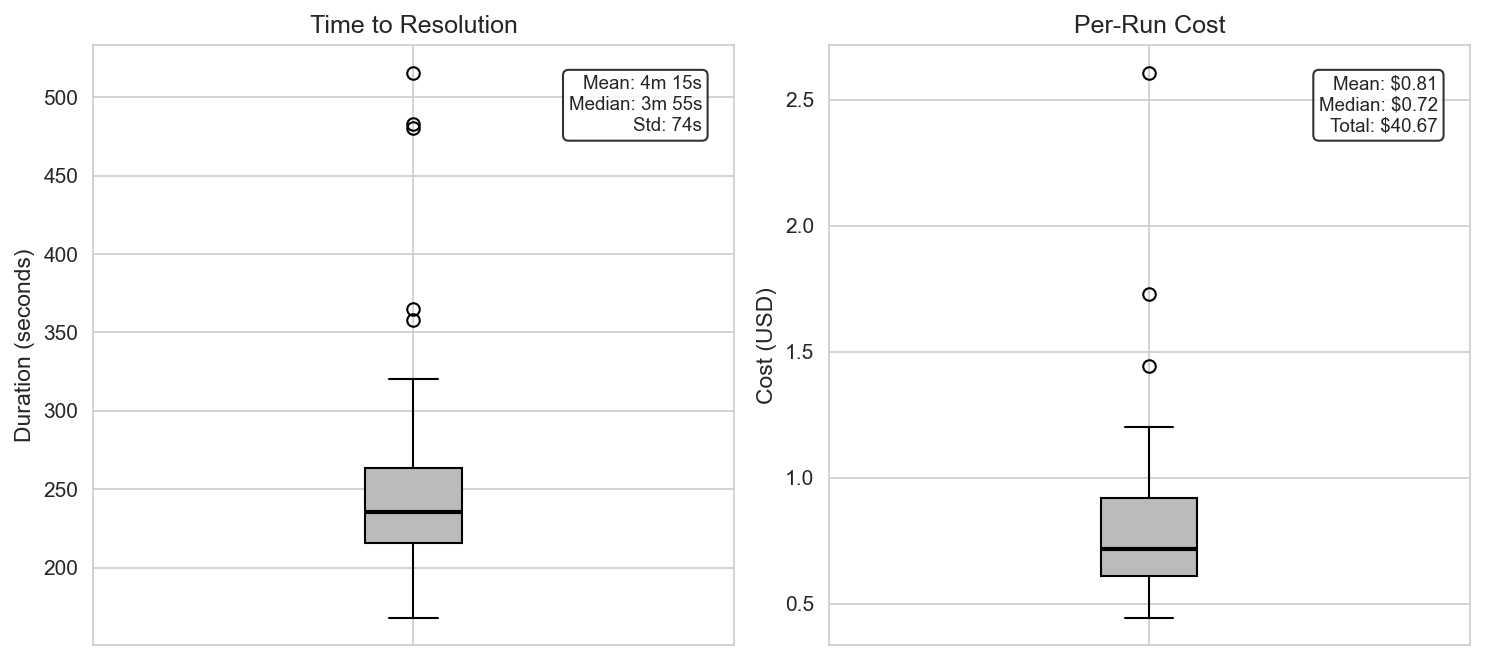

In [5]:
durations = [r['duration'] for r in transcripts['per_run']]
costs = [r['cost']['total'] for r in transcripts['per_run']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

# Duration box plot
bp1 = ax1.boxplot(durations, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#bbbbbb', edgecolor='black'),
                   medianprops=dict(color='black', linewidth=2))
ax1.set_ylabel('Duration (seconds)')
ax1.set_title('Time to Resolution')
ax1.set_xticklabels([''])

# Add mm:ss secondary labels
dur_stats = transcripts['aggregate']['duration']['stats']
def fmt_time(s):
    return f'{int(s)//60}m {int(s)%60:02d}s'
stats_text = f"Mean: {fmt_time(dur_stats['mean'])}\nMedian: {fmt_time(dur_stats['median'])}\nStd: {dur_stats['stdev']:.0f}s"
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8))

# Cost box plot
bp2 = ax2.boxplot(costs, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#bbbbbb', edgecolor='black'),
                   medianprops=dict(color='black', linewidth=2))
ax2.set_ylabel('Cost (USD)')
ax2.set_title('Per-Run Cost')
ax2.set_xticklabels([''])

cost_stats = transcripts['aggregate']['cost']['per_run']['total']
stats_text = f"Mean: ${cost_stats['mean']:.2f}\nMedian: ${cost_stats['median']:.2f}\nTotal: ${sum(costs):.2f}"
ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8))

plt.tight_layout()
all_figures.append(('fig3_duration_cost', fig))
plt.show()

## Figure 4 — Cost Breakdown by Component

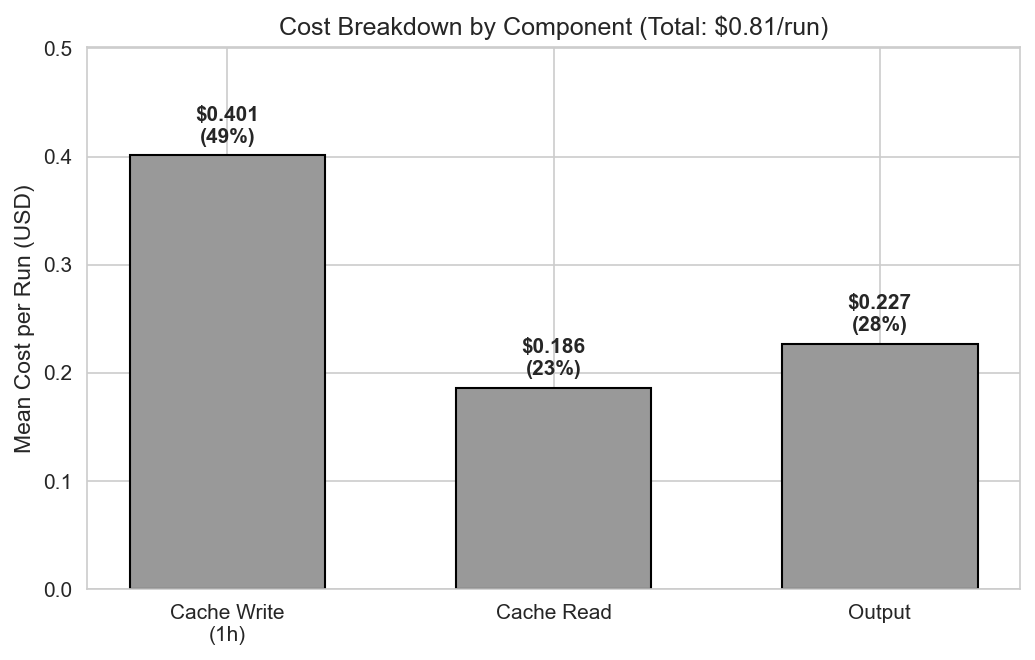

In [6]:
cost_components = transcripts['aggregate']['cost']['per_run']
# Only show components with non-negligible mean values
components = ['cache_write_1h', 'cache_read', 'output', 'input', 'cache_write_5m']
labels = ['Cache Write\n(1h)', 'Cache Read', 'Output', 'Input', 'Cache Write\n(5m)']
means = [cost_components[c]['mean'] for c in components]

# Filter out zero/negligible components
nonzero = [(l, m) for l, m in zip(labels, means) if m > 0.001]
labels_nz, means_nz = zip(*nonzero)
total = sum(means_nz)

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(means_nz))

bars = ax.bar(x, means_nz, color='#999999', edgecolor='black', width=0.6)

# Annotate each bar with dollar amount and percentage
for bar, mean in zip(bars, means_nz):
    pct = mean / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'${mean:.3f}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_nz)
ax.set_ylabel('Mean Cost per Run (USD)')
ax.set_title(f'Cost Breakdown by Component (Total: ${total:.2f}/run)')
ax.set_ylim(0, max(means_nz) * 1.25)

plt.tight_layout()
all_figures.append(('fig4_cost_breakdown', fig))
plt.show()

## Figure 5 — Phase Distribution per Run (Diagnose / Fix / Verify)

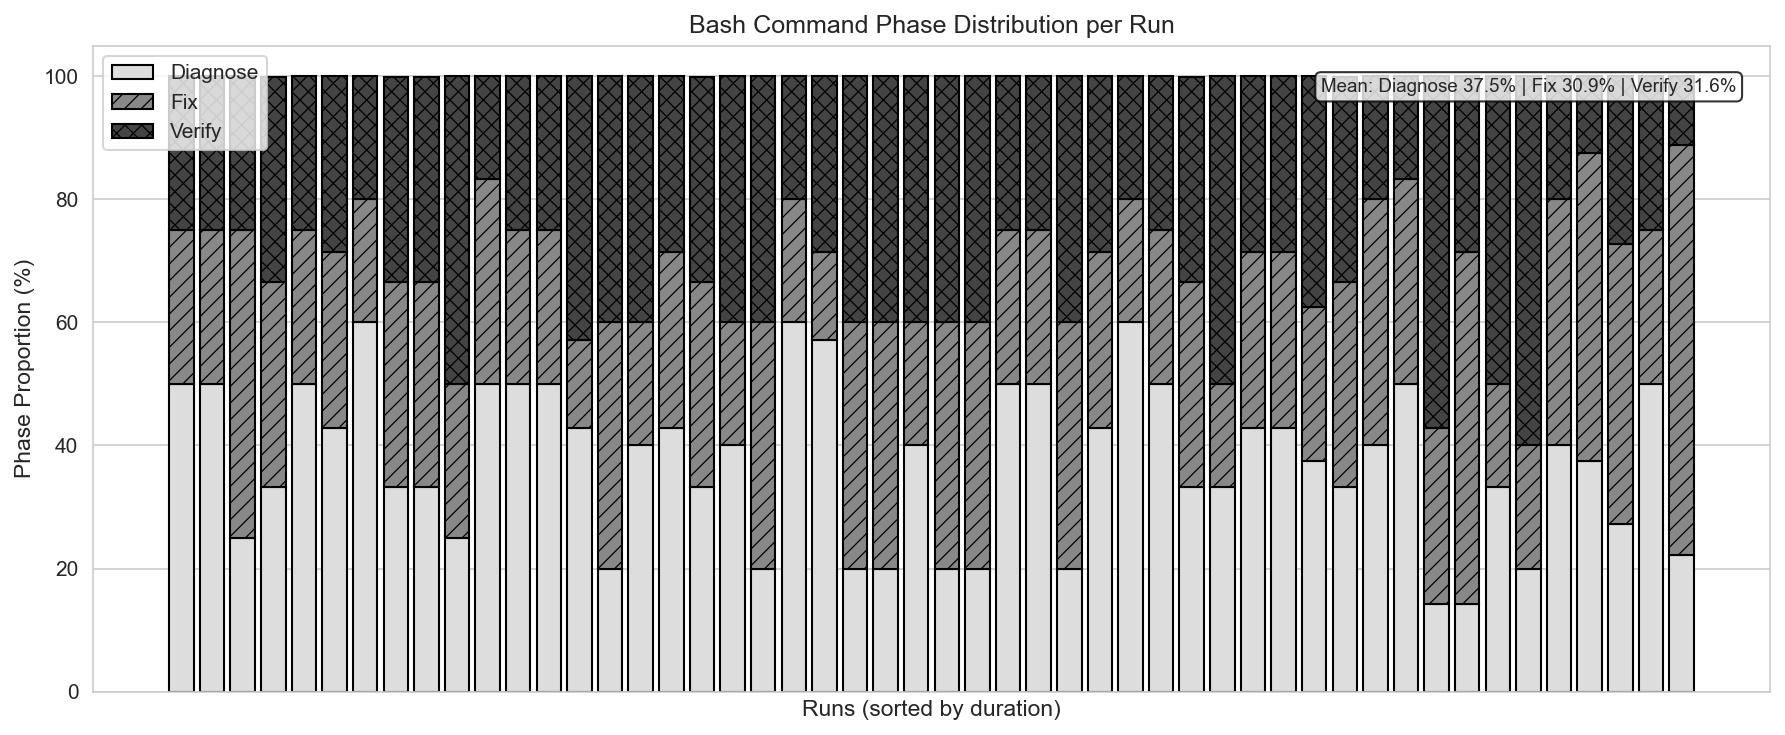

In [7]:
phase_data = []
for r in transcripts['per_run']:
    phase_data.append({
        'run': r['name'],
        'duration': r['duration'],
        'diagnose': r['behavior']['phase_pcts'].get('diagnose', 0),
        'fix': r['behavior']['phase_pcts'].get('fix', 0),
        'verify': r['behavior']['phase_pcts'].get('verify', 0),
    })

phase_df = pd.DataFrame(phase_data).sort_values('duration').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(phase_df))

ax.bar(x, phase_df['diagnose'], label='Diagnose',
       color='#dddddd', edgecolor='black')
ax.bar(x, phase_df['fix'], bottom=phase_df['diagnose'], label='Fix',
       color='#888888', edgecolor='black', hatch='///')
ax.bar(x, phase_df['verify'], bottom=phase_df['diagnose'] + phase_df['fix'], label='Verify',
       color='#444444', edgecolor='black', hatch='xxx')

ax.set_xlabel('Runs (sorted by duration)')
ax.set_ylabel('Phase Proportion (%)')
ax.set_title('Bash Command Phase Distribution per Run')
ax.legend(loc='upper left')
ax.set_xticks([])
ax.set_ylim(0, 105)

# Add mean line annotations
agg_behavior = transcripts['aggregate']['behavior']
mean_diag = agg_behavior['phase_pcts']['diagnose']['mean']
mean_fix = agg_behavior['phase_pcts']['fix']['mean']
mean_ver = agg_behavior['phase_pcts']['verify']['mean']
ax.text(0.98, 0.95, f'Mean: Diagnose {mean_diag:.1f}% | Fix {mean_fix:.1f}% | Verify {mean_ver:.1f}%',
        transform=ax.transAxes, fontsize=9, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8))

plt.tight_layout()
all_figures.append(('fig5_phase_distribution', fig))
plt.show()

## Figure 6 — Fix Target Order

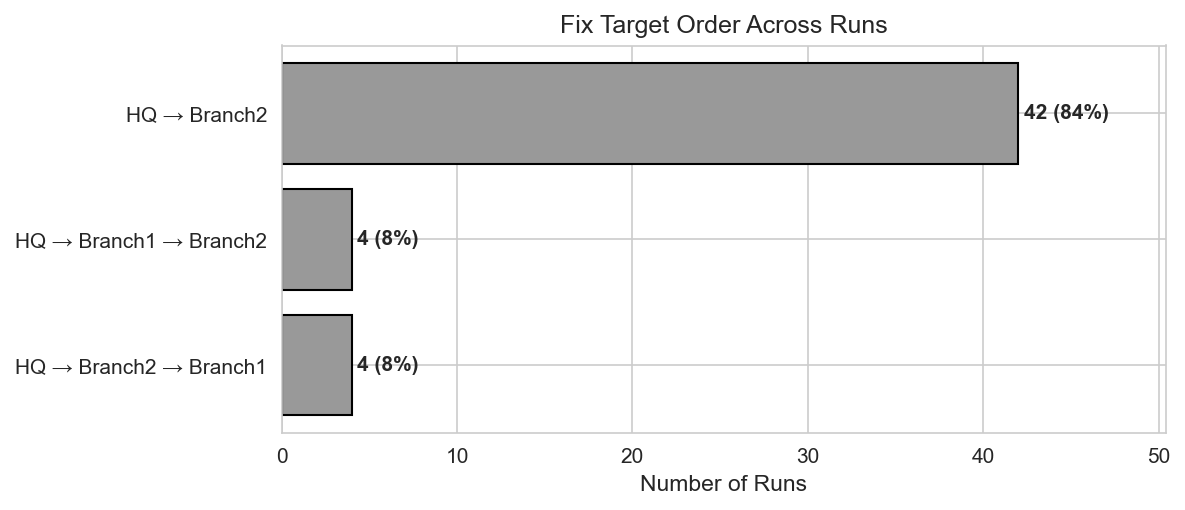

In [8]:
# Count fix order patterns
fix_orders = [' → '.join(r['behavior']['fix_order']) for r in transcripts['per_run']]
order_counts = Counter(fix_orders)
order_sorted = order_counts.most_common()

labels = [o[0] for o in order_sorted]
counts = [o[1] for o in order_sorted]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(labels, counts, color='#999999', edgecolor='black')

for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{count} ({count*2}%)', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Runs')
ax.set_title('Fix Target Order Across Runs')
ax.set_xlim(0, max(counts) * 1.2)
ax.invert_yaxis()

plt.tight_layout()
all_figures.append(('fig6_fix_order', fig))
plt.show()